# Spam SMS Detection

This project builds machine learning models to classify SMS messages as **spam** or **legitimate (ham)**.

## Workflow
- Load and explore the SMS dataset
- Clean the messages
- Split data into training and testing sets
- Convert text into TF-IDF features
- Train Naive Bayes, Logistic Regression, and SVM models
- Compare model performance
- Predict new SMS messages

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [7]:
data = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())
print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (5572, 5)

Column names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## 3. Prepare Dataset

In [8]:
# The common SMS Spam Collection format contains the label in the first
# column and the message in the second column. Extra unnamed columns are removed.

if data.shape[1] >= 2:
    data = data.iloc[:, :2].copy()
    data.columns = ["label", "message"]

data = data.dropna(subset=["label", "message"]).copy()

# Convert labels to standard names
data["label"] = data["label"].astype(str).str.lower().str.strip()
data["message"] = data["message"].astype(str)

print("Prepared dataset shape:", data.shape)
display(data.head())

Prepared dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 4. Explore Dataset

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


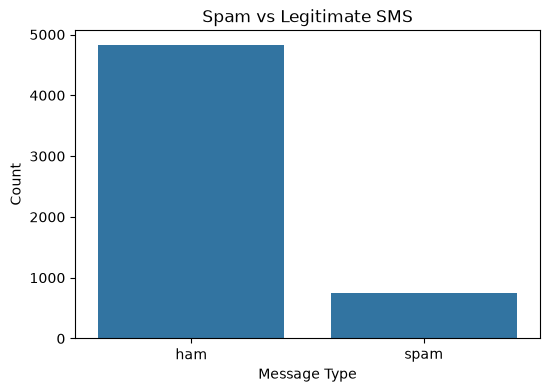

In [9]:
print("Class distribution:")
print(data["label"].value_counts())

print("\nMissing values:")
print(data.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="label")
plt.title("Spam vs Legitimate SMS")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

## 5. Encode Labels and Split Data

In [10]:
# ham = 0 (legitimate), spam = 1
data["label_encoded"] = data["label"].map({"ham": 0, "spam": 1})

# Remove rows with unexpected labels, if any
data = data.dropna(subset=["label_encoded"]).copy()
data["label_encoded"] = data["label_encoded"].astype(int)

X = data["message"]
y = data["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


## 6. TF-IDF Feature Extraction

In [11]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 10000)
Testing TF-IDF shape: (1115, 10000)


## 7. Naive Bayes

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, zero_division=0)
nb_recall = recall_score(y_test, nb_pred, zero_division=0)
nb_f1 = f1_score(y_test, nb_pred, zero_division=0)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Legitimate", "Spam"],
    zero_division=0
))

Naive Bayes Results
-------------------
Accuracy : 0.9668161434977578
Precision: 1.0
Recall   : 0.7516778523489933
F1 Score : 0.8582375478927203

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98       966
        Spam       1.00      0.75      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



## 8. Logistic Regression

In [13]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Legitimate", "Spam"],
    zero_division=0
))

Logistic Regression Results
---------------------------
Accuracy : 0.9847533632286996
Precision: 0.9583333333333334
Recall   : 0.9261744966442953
F1 Score : 0.9419795221843004

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99       966
        Spam       0.96      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



## 9. Support Vector Machine

In [14]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, zero_division=0)

print("SVM Results")
print("-----------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Legitimate", "Spam"],
    zero_division=0
))

SVM Results
-----------
Accuracy : 0.9847533632286996
Precision: 0.9782608695652174
Recall   : 0.9060402684563759
F1 Score : 0.9407665505226481

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99       966
        Spam       0.98      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



## 10. Model Comparison

In [15]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        svm_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        svm_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1,
        svm_f1
    ]
})

display(results)

best_model_name = results.loc[results["F1 Score"].idxmax(), "Model"]

if best_model_name == "Naive Bayes":
    best_model = nb_model
elif best_model_name == "Logistic Regression":
    best_model = lr_model
else:
    best_model = svm_model

print("Best model based on F1 Score:", best_model_name)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.966816,1.000000,0.751678,0.858238
1,Logistic Regression,0.984753,0.958333,0.926174,0.941980
2,Support Vector Machine,0.984753,0.978261,0.906040,0.940767


Best model based on F1 Score: Logistic Regression


## 11. Confusion Matrix for Best Model

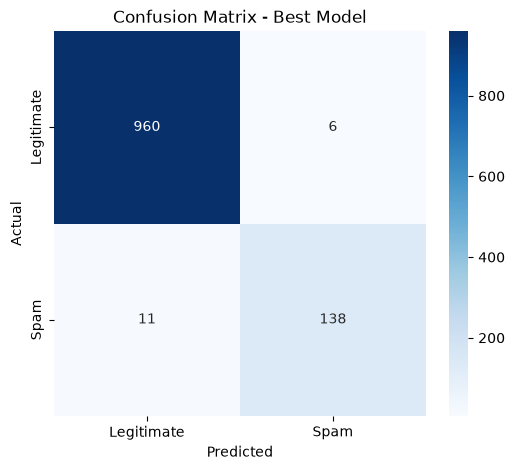

In [16]:
best_pred = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Spam"],
    yticklabels=["Legitimate", "Spam"]
)
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12. Test New SMS Messages

In [17]:
new_messages = [
    "Congratulations! You have won a free prize. Call now to claim it.",
    "Hey bro, are we meeting for class tomorrow?"
]

new_messages_tfidf = tfidf.transform(new_messages)
new_predictions = best_model.predict(new_messages_tfidf)

for message, prediction in zip(new_messages, new_predictions):
    result = "SPAM" if prediction == 1 else "LEGITIMATE"
    print("Message:", message)
    print("Prediction:", result)
    print("-" * 70)

Message: Congratulations! You have won a free prize. Call now to claim it.
Prediction: SPAM
----------------------------------------------------------------------
Message: Hey bro, are we meeting for class tomorrow?
Prediction: LEGITIMATE
----------------------------------------------------------------------


## 13. Try Your Own SMS

In [18]:
user_message = input("Enter an SMS message: ")

if user_message.strip():
    user_message_tfidf = tfidf.transform([user_message])
    user_prediction = best_model.predict(user_message_tfidf)[0]

    print("\nPrediction:", "SPAM" if user_prediction == 1 else "LEGITIMATE")
else:
     print("No message entered.")


Prediction: SPAM


## 14. Save Predictions

In [19]:
prediction_output = pd.DataFrame({
    "message": X_test.values,
    "actual": y_test.values,
    "predicted": best_pred
})

prediction_output["actual"] = prediction_output["actual"].map({
    0: "legitimate",
    1: "spam"
})

prediction_output["predicted"] = prediction_output["predicted"].map({
    0: "legitimate",
    1: "spam"
})

prediction_output.to_csv("spam_predictions.csv", index=False)

print("Predictions saved as spam_predictions.csv")

Predictions saved as spam_predictions.csv


## 15. Conclusion

The SMS messages were converted into numerical TF-IDF features and classified using Naive Bayes, Logistic Regression, and Support Vector Machine models.

The models were compared using accuracy, precision, recall, and F1 score. The model with the highest F1 score was selected for the final SMS classification.

The final system can classify new SMS messages as **spam** or **legitimate** based on patterns learned from the training dataset.